# Figure 2: In-Distribution Risk Panels

This notebook consumes JSON files generated by `scripts/reproduce_eval.sh` and renders the four in-distribution risk panels. Each plotting cell loads one canonical JSON file and writes one PDF under `figures/output/`.


In [1]:
# Shared imports and Matplotlib style defaults for all Fig. 2 panels.
import json
import pathlib
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
import matplotlib as mpl
mpl.rcParams['axes.linewidth'] = 1.3


# CLIP risk plot

## Fig. 2a: CLIP Risk

Loads `clip-risk.json`, which contains CLIP loss histories and the Bayes baseline across the p-flip grid.


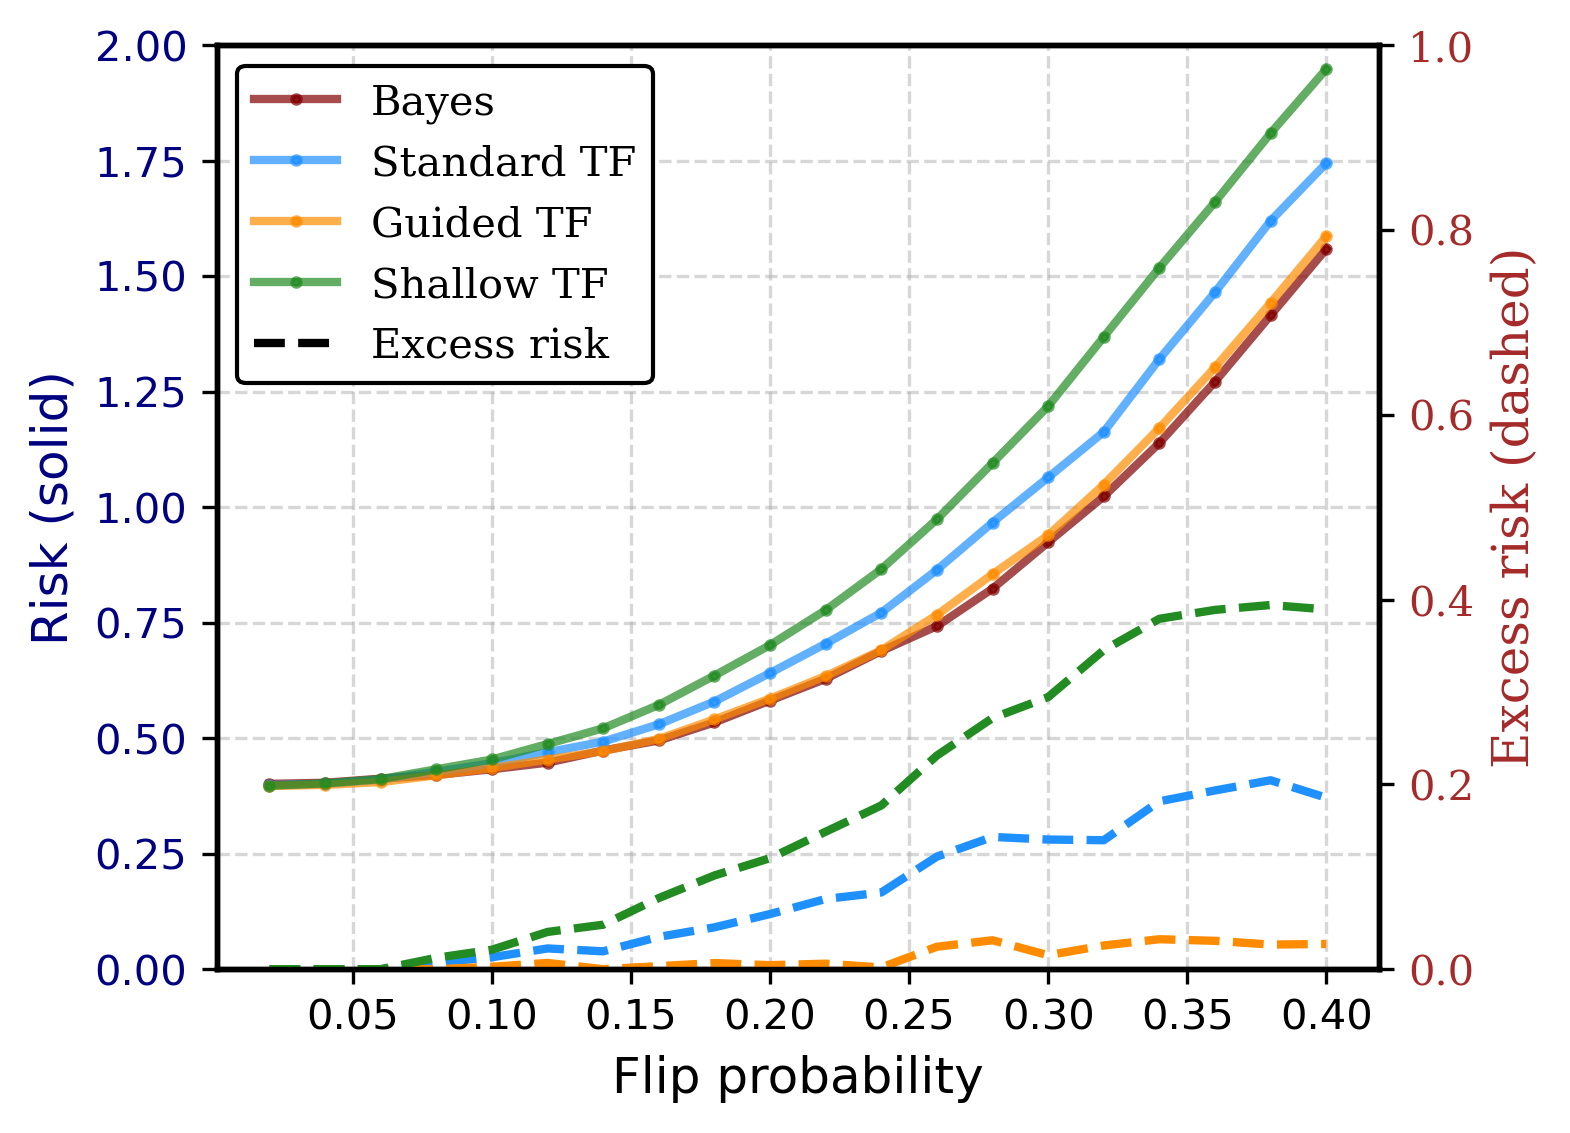

In [2]:
# Load CLIP risk data and render Fig. 2a.

with open("./data/ghm-data/clip-risk.json", "r") as f:
    data_dict = json.load(f)
fig, ax1 = plt.subplots(figsize=(5, 4),dpi=300)

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
})
colors = {
    "Bayes": "maroon",
    "Standard TF": "dodgerblue",
    "Guided TF": "darkorange",
    "Shallow TF": "forestgreen",
}

p_flip = np.array(data_dict["p_flip"])/100
run_types = list(colors.keys())
for model_type in run_types:
    ax1.plot(p_flip, data_dict[model_type], label=model_type, color=colors[model_type], linewidth=2, marker="o", markersize=2, alpha=0.7)
ax1.set_xlabel("Flip probability", fontsize=12)
ax1.set_ylabel(r"Risk (solid)", color="navy", fontsize=12)
ax1.tick_params(axis="y", labelcolor="navy")
ax1.grid(True, ls="--", alpha=0.5)
ax1.set_ylim(0, 2)
# ax1.set_xlim(0, 0.4)

ax2 = ax1.twinx()
for model_type in run_types[1:]:
    y_model = np.array(data_dict[model_type])
    y_bayes = np.array(data_dict["Bayes"])
    ax2.plot(p_flip, np.maximum(0, y_model - y_bayes), label="_nolegend_", color=colors[model_type], linestyle="--", linewidth=2)


# Right-axis formatting
ax2.set_ylabel(r"Excess risk (dashed)", color="brown", fontsize=12)
ax2.tick_params(axis="y", labelcolor="brown")
lines_labels = [ax1.get_lines()[i] for i in range(len(colors))]
labels = list(colors.keys())
extra_line = plt.Line2D([], [], color="black", ls="--", lw=2, label="Excess risk")
lines_labels.append(extra_line)
labels.append("Excess risk")
ax2.set_ylim(0,1)
# ax2.set_xlim(0, 0.4)
legend = ax1.legend(lines_labels, labels, loc="upper left",
                    frameon=True, fancybox=True, framealpha=1, facecolor="white", edgecolor="black")
legend.get_frame().set_linewidth(1.0)
plt.savefig("./output/Fig2-a-CLIP-risk.pdf", format="pdf", dpi=300, bbox_inches="tight")


# ZSC risk

## Fig. 2b: Zero-Shot Classification Risk

Loads `zsc-risk.json`, which evaluates CLIP zero-shot classification at a fixed support size over the p-flip grid.


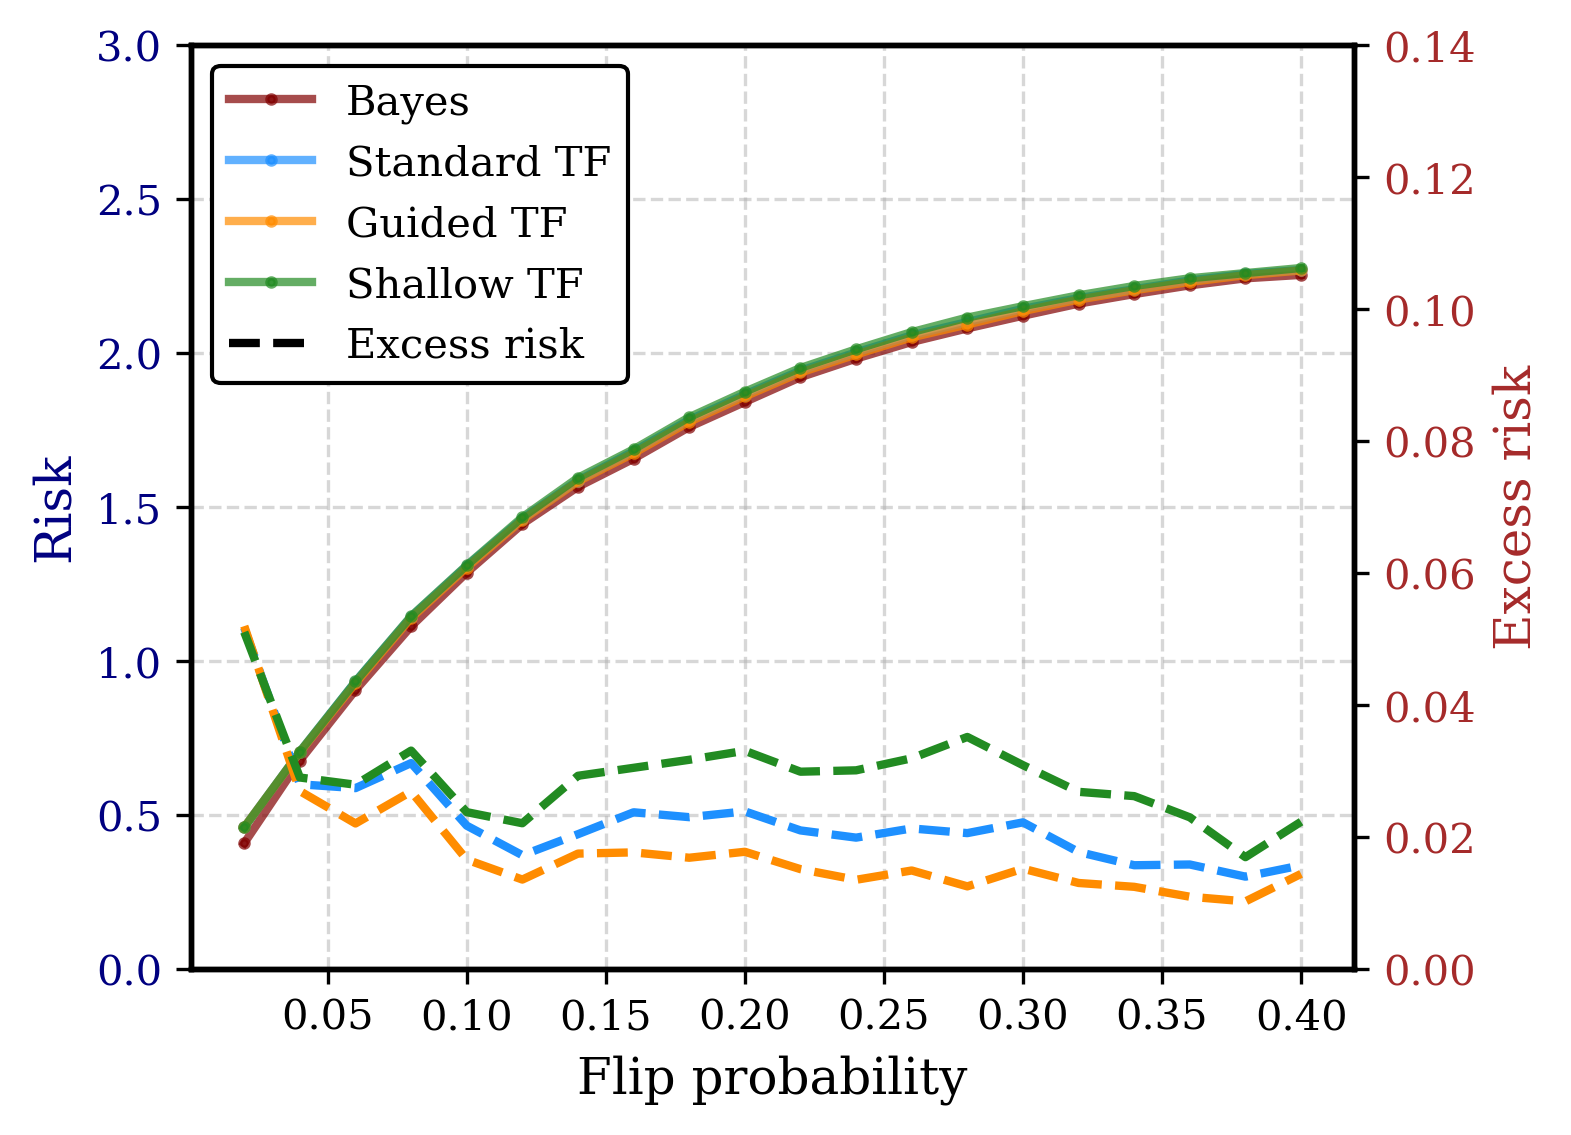

In [3]:
# Load zero-shot risk data and render Fig. 2b.
with open("./data/ghm-data/zsc-risk.json", "r") as f:
    data_dict = json.load(f)

fig, ax1 = plt.subplots(figsize=(5, 4),dpi=300)

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
})
colors = {
    "Bayes": "maroon",
    "Standard TF": "dodgerblue",
    "Guided TF": "darkorange",
    "Shallow TF": "forestgreen",
}

p_flip = np.array(data_dict["p_flip"])/100
run_types = list(colors.keys())
for model_type in run_types:
    ax1.plot(p_flip, data_dict[model_type], label=model_type, color=colors[model_type], linewidth=2, marker="o", markersize=2, alpha=0.7)
ax1.set_xlabel("Flip probability", fontsize=12)
ax1.set_ylabel(r"Risk", color="navy", fontsize=12)
ax1.tick_params(axis="y", labelcolor="navy")
ax1.grid(True, ls="--", alpha=0.5)
ax1.set_ylim(0, 3)
# ax1.set_xlim(0, 0.4)

ax2 = ax1.twinx()
for model_type in run_types[1:]:
    y_model = np.array(data_dict[model_type])
    y_bayes = np.array(data_dict["Bayes"])
    ax2.plot(p_flip, np.maximum(0, y_model - y_bayes), label="_nolegend_", color=colors[model_type], linestyle="--", linewidth=2)


# Right-axis formatting
ax2.set_ylabel(r"Excess risk", color="brown", fontsize=12)
ax2.tick_params(axis="y", labelcolor="brown")
lines_labels = [ax1.get_lines()[i] for i in range(len(colors))]
labels = list(colors.keys())
extra_line = plt.Line2D([], [], color="black", ls="--", lw=2, label="Excess risk")
lines_labels.append(extra_line)
labels.append("Excess risk")
ax2.set_ylim(0,0.14)
# ax2.set_xlim(0, 0.4)
legend = ax1.legend(lines_labels, labels, loc="upper left",
                    frameon=True, fancybox=True, framealpha=1, facecolor="white", edgecolor="black")
legend.get_frame().set_linewidth(1.0)
plt.savefig("./output/Fig2-b-ZSC-risk.pdf", format="pdf", dpi=300, bbox_inches="tight")


# CDM risk

## Fig. 2c: Conditional Denoising Risk

Loads `cdm-risk.json`, which summarizes CDM checkpoint loss histories and Bayes baselines over p-flip.


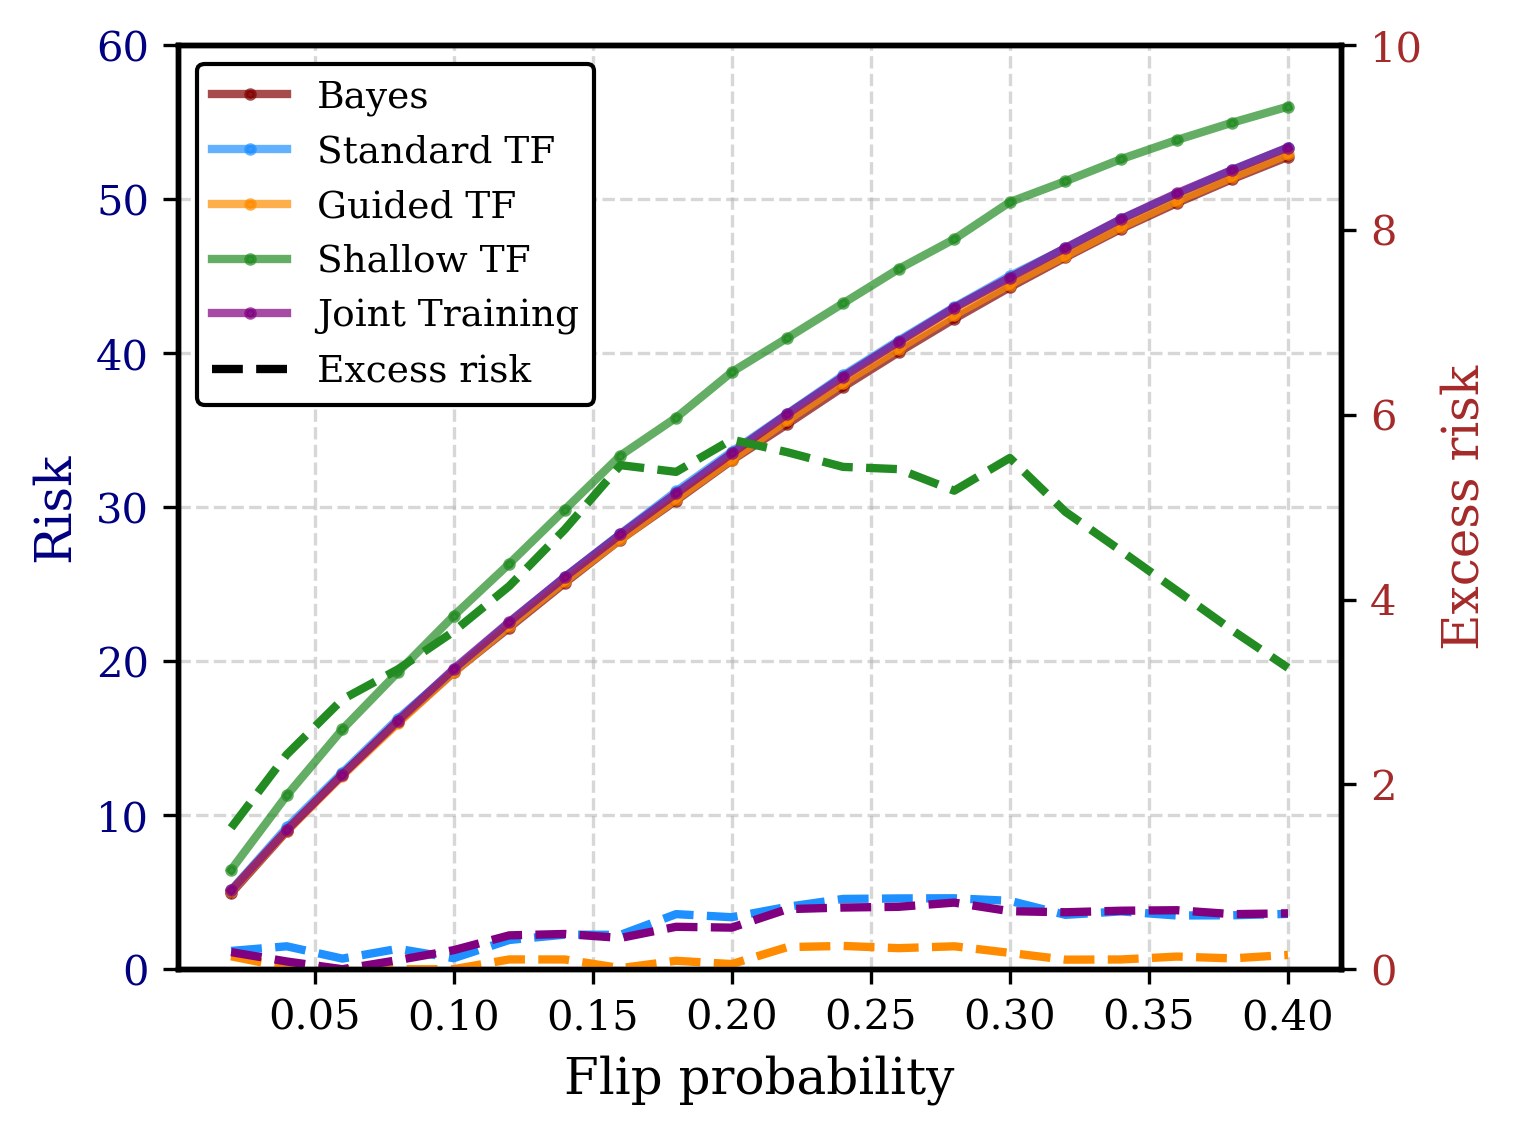

In [4]:
# Load conditional denoising risk data and render Fig. 2c.
with open("./data/ghm-data/cdm-risk.json", "r") as f:
    data_dict = json.load(f)

fig, ax1 = plt.subplots(figsize=(5, 4),dpi=300)

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
})
colors = {
    "Bayes": "maroon",
    "Standard TF": "dodgerblue",
    "Guided TF": "darkorange",
    "Shallow TF": "forestgreen",
    "Joint Training": "purple",
}

p_flip = np.array(data_dict["p_flip"])/100
run_types = list(colors.keys())
for model_type in run_types:
    ax1.plot(p_flip, data_dict[model_type], label=model_type, color=colors[model_type], linewidth=2, marker="o", markersize=2, alpha=0.7)
ax1.set_xlabel("Flip probability", fontsize=12)
ax1.set_ylabel(r"Risk", color="navy", fontsize=12)
ax1.tick_params(axis="y", labelcolor="navy")
ax1.grid(True, ls="--", alpha=0.5)
ax1.set_ylim(0, 60)
# ax1.set_xlim(0, 0.4)

ax2 = ax1.twinx()
for model_type in run_types[1:]:
    y_model = np.array(data_dict[model_type])
    y_bayes = np.array(data_dict["Bayes"])
    ax2.plot(p_flip, np.maximum(0, y_model - y_bayes), label="_nolegend_", color=colors[model_type], linestyle="--", linewidth=2)


# Right-axis formatting
ax2.set_ylabel(r"Excess risk", color="brown", fontsize=12)
ax2.tick_params(axis="y", labelcolor="brown")
lines_labels = [ax1.get_lines()[i] for i in range(len(colors))]
labels = list(colors.keys())
extra_line = plt.Line2D([], [], color="black", ls="--", lw=2, label="Excess risk")
lines_labels.append(extra_line)
labels.append("Excess risk")
ax2.set_ylim(0,10)
# ax2.set_xlim(0, 0.4)
legend = ax1.legend(lines_labels, labels, loc="upper left",
                    frameon=True, fancybox=True, framealpha=1, facecolor="white", edgecolor="black",fontsize=9)
legend.get_frame().set_linewidth(1.0)
plt.savefig("./output/Fig2-c-CDM-risk.pdf", format="pdf", dpi=300, bbox_inches="tight")


## Fig. 2d: Next-Word-Prediction Risk

Loads `vlm-risk.json`, which summarizes VLM checkpoint loss histories and Bayes baselines over p-flip.


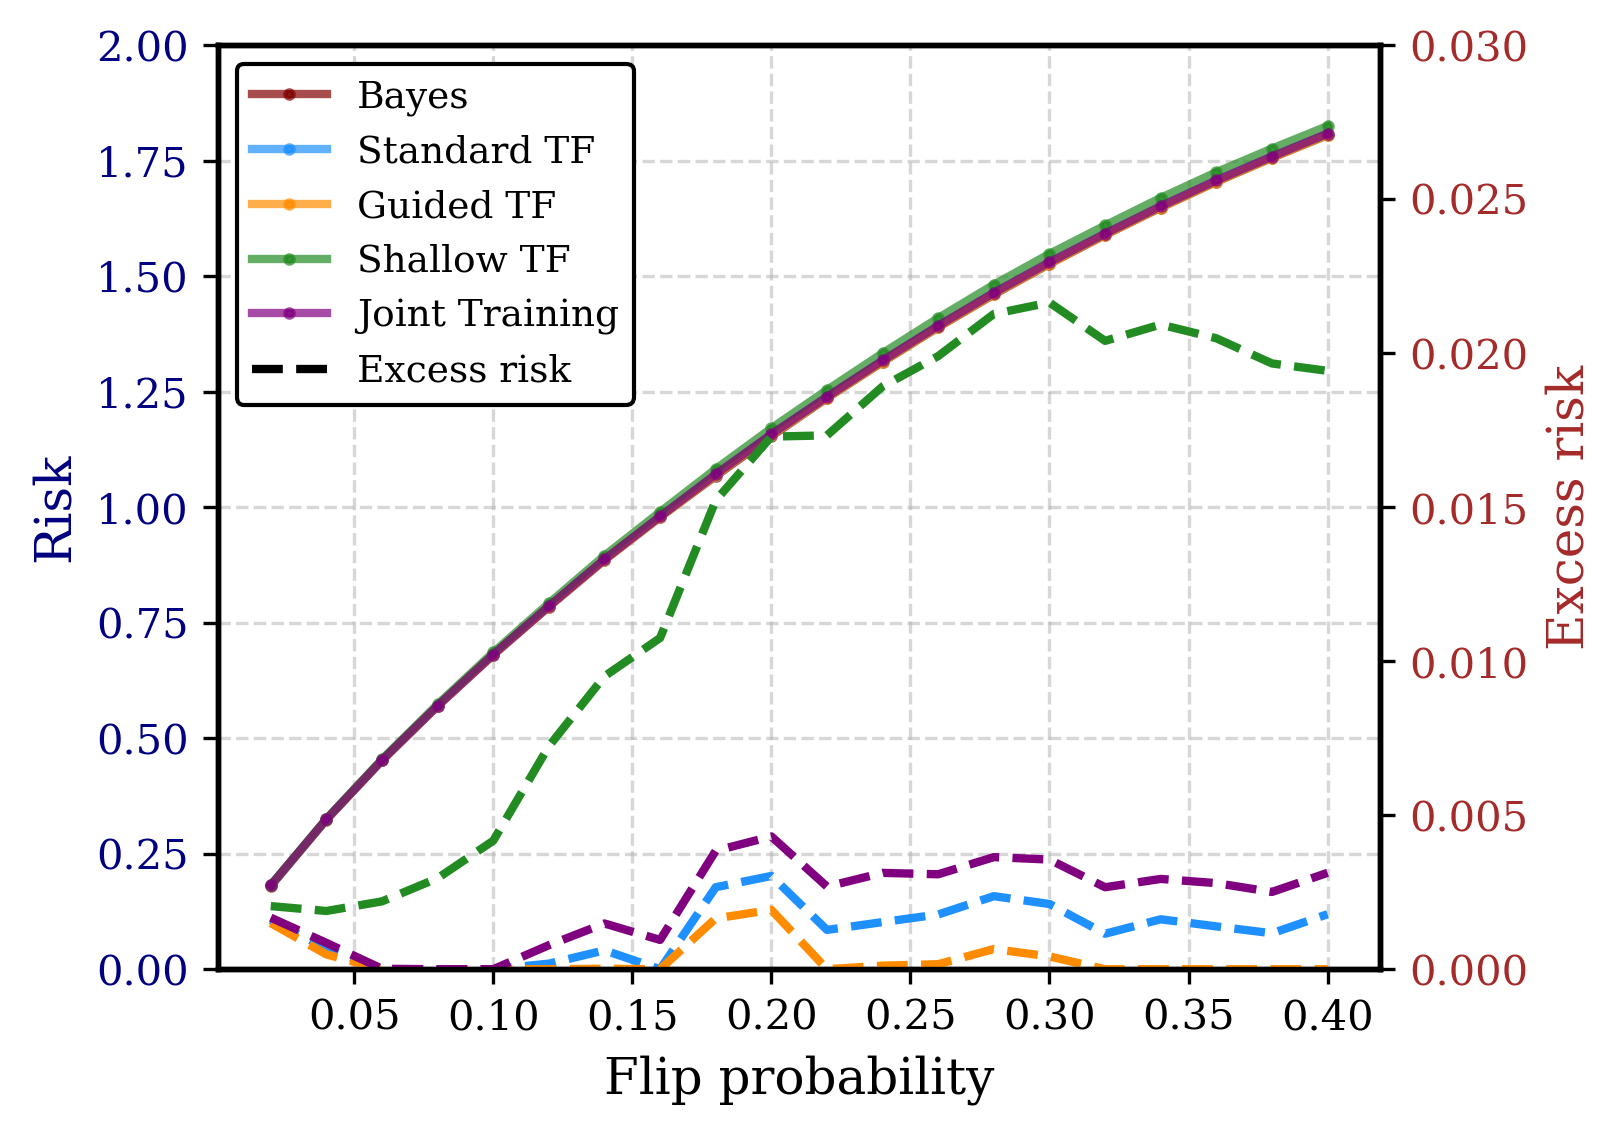

In [5]:
# Load next-word-prediction risk data and render Fig. 2d.
with open("./data/ghm-data/vlm-risk.json", "r") as f:
    data_dict = json.load(f)

fig, ax1 = plt.subplots(figsize=(5, 4),dpi=300)

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
})
colors = {
    "Bayes": "maroon",
    "Standard TF": "dodgerblue",
    "Guided TF": "darkorange",
    "Shallow TF": "forestgreen",
    "Joint Training": "purple",
}

p_flip = np.array(data_dict["p_flip"])/100
run_types = list(colors.keys())
for model_type in run_types:
    ax1.plot(p_flip, data_dict[model_type], label=model_type, color=colors[model_type], linewidth=2, marker="o", markersize=2, alpha=0.7)
ax1.set_xlabel("Flip probability", fontsize=12)
ax1.set_ylabel(r"Risk", color="navy", fontsize=12)
ax1.tick_params(axis="y", labelcolor="navy")
ax1.grid(True, ls="--", alpha=0.5)
ax1.set_ylim(0, 2)
# ax1.set_xlim(0, 0.4)

ax2 = ax1.twinx()
for model_type in run_types[1:]:
    y_model = np.array(data_dict[model_type])
    y_bayes = np.array(data_dict["Bayes"])
    ax2.plot(p_flip, np.maximum(0, y_model - y_bayes), label="_nolegend_", color=colors[model_type], linestyle="--", linewidth=2)


# Right-axis formatting
ax2.set_ylabel(r"Excess risk", color="brown", fontsize=12)
ax2.tick_params(axis="y", labelcolor="brown")
lines_labels = [ax1.get_lines()[i] for i in range(len(colors))]
labels = list(colors.keys())
extra_line = plt.Line2D([], [], color="black", ls="--", lw=2, label="Excess risk")
lines_labels.append(extra_line)
labels.append("Excess risk")
ax2.set_ylim(0,0.03)
# ax2.set_xlim(0, 0.4)
legend = ax1.legend(lines_labels, labels, loc="upper left",
                    frameon=True, fancybox=True, framealpha=1, facecolor="white", edgecolor="black",fontsize=9)
legend.get_frame().set_linewidth(1.0)
plt.savefig("./output/Fig2-d-VLM-risk.pdf", format="pdf", dpi=300)
